In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
data=pd.read_csv("/content/fake_job_postings.csv", encoding='latin1', on_bad_lines='skip', engine='python')
print(data.head())

   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         description  \
0  Foo

In [ ]:
data = data[['title', 'description', 'fraudulent','salary_range','company_profile','location']].copy()
data['title'] = data['title'].fillna("")
data['description'] = data['description'].fillna("")
data['company_profile'] = data['company_profile'].fillna("")
data['location'] = data['location'].fillna("")
data['salary_range'] = data['salary_range'].fillna("")
data['text'] = data['title'] + " " + data['description']+" "+data['company_profile']+" "+data['location']+" "+data['salary_range']
print(data.head())


                                       title  \
0                           Marketing Intern   
1  Customer Service - Cloud Video Production   
2    Commissioning Machinery Assistant (CMA)   
3          Account Executive - Washington DC   
4                        Bill Review Manager   

                                         description  fraudulent salary_range  \
0  Food52, a fast-growing, James Beard Award-winn...         0.0                
1  Organised - Focused - Vibrant - Awesome!Do you...         0.0                
2  Our client, located in Houston, is actively se...         0.0                
3  THE COMPANY: ESRI â Environmental Systems Re...         0.0                
4  JOB TITLE: Itemization Review ManagerLOCATION:...         0.0                

                                     company_profile            location  \
0  We're Food52, and we've created a groundbreaki...    US, NY, New York   
1  90 Seconds, the worlds Cloud Video Production ...      NZ, , Auckland

In [ ]:
#text cleaning
def clean_text(text):
  text=text.lower()
  text=re.sub(r'[^a-zA-Z0-9]'," ",text)
  text=re.sub(r'\s+'," ",text)
  return text
data['text']=data['text'].apply(clean_text)

In [ ]:
tokenizer=Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data['text'])
sequences=tokenizer.texts_to_sequences(data['text'])
X=pad_sequences(sequences,maxlen=100)
y=data['fraudulent']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64))
model.add(LSTM(64))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9611 - loss: nan - val_accuracy: 0.9731 - val_loss: nan
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9702 - loss: nan - val_accuracy: 0.9731 - val_loss: nan
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9702 - loss: nan - val_accuracy: 0.9731 - val_loss: nan
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.9702 - loss: nan - val_accuracy: 0.9731 - val_loss: nan
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.9702 - loss: nan - val_accuracy: 0.9731 - val_loss: nan


In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Accuracy: 0.9731285988483686
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       507
         1.0       0.00      0.00      0.00        14

    accuracy                           0.97       521
   macro avg       0.49      0.50      0.49       521
weighted avg       0.95      0.97      0.96       521



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def predict_job(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=100)

    pred = model.predict(padded)

    if pred > 0.8:
      return("Fake Job")
    elif pred> 0.6:
      return("Suspicious Job")
    else:
      return("Real Job")

print(predict_job("""Job Title: Data Analyst Intern

Company: Insight Analytics Pvt. Ltd.
Location: Work from Home
Duration: 2 Months
Stipend: ₹8,000/month

About the Role:
Insight Analytics is seeking a Data Analyst Intern to assist in analyzing datasets and generating meaningful insights. The intern will work closely with the analytics team on real-world business problems.

Responsibilities:
- Collect, clean, and analyze data from various sources
- Create reports and dashboards using tools like Excel or Power BI
- Assist in identifying trends and patterns in data
- Support the team in data-driven decision-making
- Document findings and present results clearly

Requirements:
- Basic knowledge of Python or SQL
- Familiarity with Excel or data visualization tools
- Understanding of statistics and data analysis concepts
- Good analytical and problem-solving skills
- Strong communication skills

Perks:
- Certificate of completion
- Letter of recommendation
- Flexible working hours
- Opportunity to work on real datasets

Who Can Apply:
- Students available for a work-from-home internship
- Can commit for 2 months
- Have relevant skills and interest in data analysis

About the Company:
Insight Analytics Pvt. Ltd. provides data-driven solutions to businesses across finance, retail, and healthcare sectors."""))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Real Job


<Axes: xlabel='fraudulent', ylabel='count'>

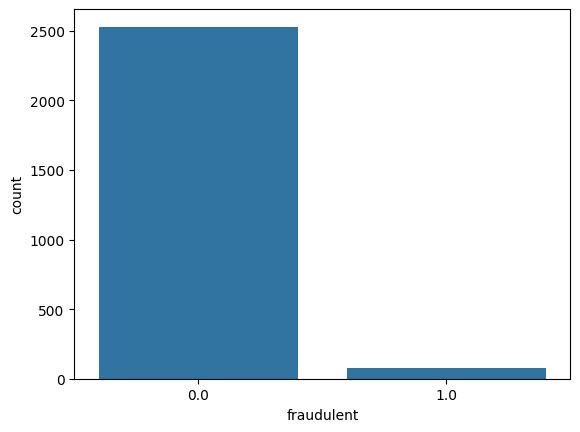

In [ ]:
import seaborn as sns
sns.countplot(x='fraudulent', data=data)

<Axes: xlabel='text_length', ylabel='Count'>

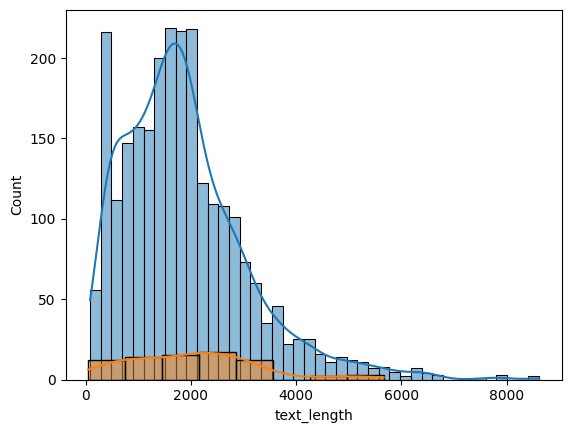

In [ ]:
data['text_length'] = data['text'].apply(len)

sns.histplot(data[data['fraudulent']==0]['text_length'], label='Real', kde=True)
sns.histplot(data[data['fraudulent']==1]['text_length'], label='Fake', kde=True)

In [ ]:
# Install dependencies
!pip install flask flask-cors pyngrok --quiet

import threading
import re
import pandas as pd
import numpy as np

from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Load & prepare data ──────────────────────────────────────────────────────
data = pd.read_csv("fake_job_postings.csv", encoding='latin1', on_bad_lines='warn', engine='python')
data = data[['title', 'description', 'fraudulent', 'salary_range', 'company_profile', 'location']].copy()
data['title']           = data['title'].fillna("")
data['description']     = data['description'].fillna("")
data['company_profile'] = data['company_profile'].fillna("")
data['location']        = data['location'].fillna("")
data['salary_range']    = data['salary_range'].fillna("")
data['text']            = (data['title'] + " " + data['description'] + " " +
                           data['company_profile'] + " " + data['location'] + " " +
                           data['salary_range'])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9]', " ", text)
    text = re.sub(r'\s+', " ", text)
    return text

data['text'] = data['text'].apply(clean_text)

# ── Tokenize ─────────────────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data['text'])
sequences = tokenizer.texts_to_sequences(data['text'])
X = pad_sequences(sequences, maxlen=100)
y = data['fraudulent']

# Drop any rows where fraudulent label is NaN (caused by skipped bad lines)
data = data.dropna(subset=['fraudulent'])
data['fraudulent'] = data['fraudulent'].astype(int)

# Re-tokenize after cleaning
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data['text'])
sequences = tokenizer.texts_to_sequences(data['text'])
X = pad_sequences(sequences, maxlen=100)
y = data['fraudulent'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calculate class weights for imbalanced dataset
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# ── Build & train model ───────────────────────────────────────────────────────
model = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test), class_weight=class_weights_dict)

y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ── Predict function ──────────────────────────────────────────────────────────
def predict_job(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=100)
    pred = float(model.predict(padded)[0][0])
    if pred > 0.8:
        verdict = "Fake Job"
    elif pred > 0.6:
        verdict = "Suspicious Job"
    else:
        verdict = "Real Job"
    return verdict, round(pred * 100, 1)

# ── Flask API ─────────────────────────────────────────────────────────────────
app = Flask(__name__)
CORS(app)

@app.route('/predict', methods=['POST'])
def predict():
    data_in = request.get_json()
    text = data_in.get('text', '')
    if not text.strip():
        return jsonify({'error': 'No text provided'}), 400
    verdict, prob = predict_job(text)
    return jsonify({'verdict': verdict, 'probability': prob})

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok'})

# ── Start ngrok tunnel ────────────────────────────────────────────────────────
# IMPORTANT: Add your ngrok auth token here (free at ngrok.com).
# Install your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3DDs2Yb5xIbWFvxNbjqqNorr4aa_LgB7tcdccr6eewS3PMGr") # <-- REPLACE THIS WITH YOUR TOKEN

public_url = ngrok.connect(5000)
print("\n" + "="*50)
print(f"  API running at: {public_url}")
print(f"  Copy this URL for Cell 2 below!")
print("="*50 + "\n")

# Run Flask in a background thread
def run_flask():
    app.run(port=5000, use_reloader=False)

t = threading.Thread(target=run_flask)
t.daemon = True
t.start()

ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.
/tmp/ipykernel_815/3350249813.py:23: ParserWarning: Skipping line 2607: unexpected end of data

  data = pd.read_csv("fake_job_postings.csv", encoding='latin1', on_bad_lines=

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.8301 - loss: 0.6195 - val_accuracy: 0.9539 - val_loss: 0.3552
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.9616 - loss: 0.2052 - val_accuracy: 0.9232 - val_loss: 0.2300
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9899 - loss: 0.0789 - val_accuracy: 0.9712 - val_loss: 0.1049
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9952 - loss: 0.0267 - val_accuracy: 0.9866 - val_loss: 0.0476
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9981 - loss: 0.0052 - val_accuracy: 0.9942 - val_loss: 0.0245
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Accuracy: 0.9942418426103646
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       508
           1       0.86      0.92      0.89        13

    accuracy                           0.99       521
   macro avg       0.93      0.96      0.94       521
weighted avg       0.99 

In [ ]:
from IPython.display import display, HTML

NGROK_URL = "https://e3a9-35-229-86-151.ngrok-free.app"  # ← paste your ngrok URL here

html_code = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=Syne:wght@400;500;700&family=DM+Mono:wght@400;500&display=swap" rel="stylesheet">
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    font-family: 'Syne', sans-serif;
    background: #f8f8f6;
    color: #1a1a1a;
    min-height: 100vh;
    padding: 2rem 1rem;
  }}
  .container {{ max-width: 680px; margin: 0 auto; }}

  .header {{
    display: flex; align-items: center; gap: 12px; margin-bottom: 1.5rem;
  }}
  .header-badge {{
    width: 36px; height: 36px; background: #E24B4A; border-radius: 10px;
    display: flex; align-items: center; justify-content: center; flex-shrink: 0;
  }}
  .header-badge svg {{ width: 20px; height: 20px; }}
  .header-title {{ font-size: 20px; font-weight: 700; color: #1a1a1a; letter-spacing: -0.3px; }}
  .header-sub {{ font-size: 13px; color: #777; margin-top: 2px; }}

  .stat-grid {{
    display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 8px; margin-bottom: 1.25rem;
  }}
  .stat {{
    background: #fff; border-radius: 10px; padding: 12px 14px;
    text-align: center; border: 0.5px solid #e0e0e0;
  }}
  .stat-num {{ font-size: 22px; font-weight: 700; font-family: 'DM Mono', monospace; }}
  .stat-lbl {{ font-size: 11px; color: #888; margin-top: 2px; }}

  .textarea-wrap {{ position: relative; margin-bottom: 10px; }}
  textarea {{
    width: 100%; min-height: 180px; padding: 14px 16px;
    font-family: 'DM Mono', monospace; font-size: 13px;
    color: #1a1a1a; background: #fff;
    border: 0.5px solid #ccc; border-radius: 12px;
    resize: vertical; line-height: 1.6; outline: none;
    transition: border-color 0.15s;
  }}
  textarea:focus {{ border-color: #888; }}
  textarea::placeholder {{ color: #aaa; }}
  .char-count {{
    position: absolute; bottom: 10px; right: 12px;
    font-size: 11px; color: #bbb; font-family: 'DM Mono', monospace;
  }}

  .actions {{ display: flex; gap: 8px; margin-bottom: 1.25rem; }}
  .btn-analyze {{
    flex: 1; height: 40px; background: #E24B4A; color: #fff; border: none;
    border-radius: 8px; font-family: 'Syne', sans-serif; font-size: 14px;
    font-weight: 500; cursor: pointer; transition: opacity 0.15s, transform 0.1s;
    display: flex; align-items: center; justify-content: center; gap: 6px;
  }}
  .btn-analyze:hover {{ opacity: 0.9; }}
  .btn-analyze:active {{ transform: scale(0.98); }}
  .btn-analyze:disabled {{ opacity: 0.5; cursor: not-allowed; }}
  .btn-clear {{
    height: 40px; padding: 0 18px; background: transparent; color: #555;
    border: 0.5px solid #ccc; border-radius: 8px;
    font-family: 'Syne', sans-serif; font-size: 13px; cursor: pointer;
    transition: background 0.15s;
  }}
  .btn-clear:hover {{ background: #f0f0f0; }}

  .examples-label {{
    font-size: 11px; font-weight: 500; color: #aaa;
    letter-spacing: 0.5px; text-transform: uppercase; margin-bottom: 8px;
  }}
  .example-pills {{ display: flex; flex-wrap: wrap; gap: 6px; margin-bottom: 1.25rem; }}
  .pill {{
    font-size: 12px; padding: 5px 12px; border-radius: 20px;
    border: 0.5px solid #ddd; background: #f5f5f5; color: #555;
    cursor: pointer; font-family: 'Syne', sans-serif; transition: background 0.15s;
  }}
  .pill:hover {{ background: #ebebeb; color: #1a1a1a; }}

  .result-card {{
    border-radius: 12px; border: 0.5px solid #e0e0e0;
    overflow: hidden; display: none;
    animation: pop 0.2s ease; background: #fff; margin-bottom: 1.25rem;
  }}
  @keyframes pop {{ from {{ opacity: 0; transform: translateY(6px); }} to {{ opacity: 1; transform: translateY(0); }} }}

  .result-header {{
    padding: 16px 18px 14px; display: flex; align-items: center;
    gap: 12px; border-bottom: 0.5px solid #f0f0f0;
  }}
  .verdict-icon {{
    width: 42px; height: 42px; border-radius: 10px;
    display: flex; align-items: center; justify-content: center;
    flex-shrink: 0; font-size: 20px; font-weight: 700;
  }}
  .verdict-label {{ font-size: 17px; font-weight: 700; letter-spacing: -0.2px; }}
  .verdict-sub {{ font-size: 12px; color: #888; margin-top: 2px; }}

  .conf-section {{ padding: 14px 18px; border-bottom: 0.5px solid #f0f0f0; }}
  .conf-label {{
    font-size: 11px; font-weight: 500; color: #aaa;
    letter-spacing: 0.5px; text-transform: uppercase;
    margin-bottom: 8px; display: flex; justify-content: space-between;
  }}
  .bar-track {{ height: 6px; background: #f0f0f0; border-radius: 3px; overflow: hidden; }}
  .bar-fill {{ height: 100%; border-radius: 3px; transition: width 0.6s cubic-bezier(0.25,1,0.5,1); }}

  .signals-section {{ padding: 14px 18px; }}
  .signals-title {{
    font-size: 11px; font-weight: 500; color: #aaa;
    letter-spacing: 0.5px; text-transform: uppercase; margin-bottom: 10px;
  }}
  .signal-row {{
    display: flex; align-items: center; gap: 10px;
    margin-bottom: 6px; font-size: 13px; color: #555;
  }}
  .signal-dot {{ width: 8px; height: 8px; border-radius: 50%; flex-shrink: 0; }}

  .history-section {{ margin-top: 1rem; display: none; }}
  .history-title {{
    font-size: 11px; font-weight: 500; color: #aaa;
    letter-spacing: 0.5px; text-transform: uppercase; margin-bottom: 10px;
  }}
  .history-list {{ display: flex; flex-direction: column; gap: 6px; }}
  .history-item {{
    display: flex; align-items: center; gap: 10px;
    padding: 9px 12px; background: #f7f7f5;
    border-radius: 8px; font-size: 13px;
  }}
  .history-dot {{ width: 8px; height: 8px; border-radius: 50%; flex-shrink: 0; }}
  .history-text {{ flex: 1; color: #666; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }}
  .history-verdict {{ font-size: 12px; font-weight: 500; flex-shrink: 0; }}

  .spinner {{
    display: inline-block; width: 14px; height: 14px;
    border: 2px solid rgba(255,255,255,0.4); border-top-color: #fff;
    border-radius: 50%; animation: spin 0.7s linear infinite;
  }}
  @keyframes spin {{ to {{ transform: rotate(360deg); }} }}

  .error-msg {{
    background: #fff3f3; border: 0.5px solid #f5c6c6; color: #c0392b;
    padding: 12px 16px; border-radius: 10px; font-size: 13px;
    margin-bottom: 1rem; display: none;
  }}
</style>
</head>
<body>
<div class="container">

  <div class="header">
    <div class="header-badge">
      <svg viewBox="0 0 24 24" fill="none" stroke="#fff" stroke-width="2.5" stroke-linecap="round" stroke-linejoin="round">
        <path d="M12 2L2 7l10 5 10-5-10-5z"/>
        <path d="M2 17l10 5 10-5"/>
        <path d="M2 12l10 5 10-5"/>
      </svg>
    </div>
    <div>
      <div class="header-title">Job Fraud Detector</div>
      <div class="header-sub">LSTM neural network — paste any job posting to analyze</div>
    </div>
  </div>

  <div class="stat-grid">
    <div class="stat">
      <div class="stat-num" id="statTotal">0</div>
      <div class="stat-lbl">Analyzed</div>
    </div>
    <div class="stat">
      <div class="stat-num" id="statFake" style="color:#E24B4A;">0</div>
      <div class="stat-lbl">Flagged fake</div>
    </div>
    <div class="stat">
      <div class="stat-num" id="statReal" style="color:#1D9E75;">0</div>
      <div class="stat-lbl">Likely real</div>
    </div>
  </div>

  <div class="error-msg" id="errorMsg"></div>

  <div class="textarea-wrap">
    <textarea id="jobInput" placeholder="Paste a job posting here — title, description, company, location, salary range..."></textarea>
    <div class="char-count" id="charCount">0 chars</div>
  </div>

  <div class="actions">
    <button class="btn-analyze" id="analyzeBtn" onclick="analyze()">
      <svg width="14" height="14" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2.5" stroke-linecap="round" stroke-linejoin="round">
        <circle cx="11" cy="11" r="8"/><path d="m21 21-4.35-4.35"/>
      </svg>
      Analyze posting
    </button>
    <button class="btn-clear" onclick="clearAll()">Clear</button>
  </div>

  <div class="examples-label">Try an example</div>
  <div class="example-pills">
    <button class="pill" onclick="loadExample('real')">Data Analyst Intern (real)</button>
    <button class="pill" onclick="loadExample('suspicious')">Remote Recruiter (suspicious)</button>
    <button class="pill" onclick="loadExample('fake')">Make $5000/week at home</button>
  </div>

  <div class="result-card" id="resultCard">
    <div class="result-header" id="resultHeader">
      <div class="verdict-icon" id="verdictIcon"></div>
      <div>
        <div class="verdict-label" id="verdictLabel"></div>
        <div class="verdict-sub" id="verdictSub"></div>
      </div>
    </div>
    <div class="conf-section">
      <div class="conf-label">
        <span>Fraud probability</span>
        <span id="confPct"></span>
      </div>
      <div class="bar-track">
        <div class="bar-fill" id="confBar" style="width:0%"></div>
      </div>
    </div>
    <div class="signals-section">
      <div class="signals-title">Model output</div>
      <div id="signalList"></div>
    </div>
  </div>

  <div class="history-section" id="historySection">
    <div class="history-title">Recent analyses</div>
    <div class="history-list" id="historyList"></div>
  </div>

</div>

<script>
const API_URL = "{NGROK_URL}";

const examples = {{
  real: `Job Title: Data Analyst Intern

Company: Insight Analytics Pvt. Ltd.
Location: Work from Home
Duration: 2 Months
Stipend: ₹8,000/month

About the Role:
Insight Analytics is seeking a Data Analyst Intern to assist in analyzing datasets and generating meaningful insights. The intern will work closely with the analytics team on real-world business problems.

Responsibilities:
- Collect, clean, and analyze data from various sources
- Create reports and dashboards using tools like Excel or Power BI
- Assist in identifying trends and patterns in data
- Support the team in data-driven decision-making
- Document findings and present results clearly

Requirements:
- Basic knowledge of Python or SQL
- Familiarity with Excel or data visualization tools
- Understanding of statistics and data analysis concepts
- Good analytical and problem-solving skills
- Strong communication skills

About the Company:
Insight Analytics Pvt. Ltd. provides data-driven solutions to businesses across finance, retail, and healthcare sectors.`,

  suspicious: `Job Title: Remote Talent Recruiter

Location: Work from Anywhere
Compensation: Commission-based, earn up to $3,000/month

We are looking for enthusiastic individuals to recruit candidates for our fast-growing network. No prior experience needed! You'll be working independently, setting your own schedule.

Duties:
- Post job listings on various platforms
- Screen candidates via WhatsApp
- Forward resumes to our central team

Requirements:
- Must have a smartphone
- Reliable internet connection
- Motivated and self-driven

Note: A refundable registration fee of ₹500 applies to cover onboarding costs.
Contact us on Telegram @recruiter_global to get started!`,

  fake: `Job Title: Work From Home - Earn $5000 Every Week!

Company: Global Opportunities Inc.
Location: Worldwide Remote
Salary: $5000-$10000/week guaranteed

Are you tired of your 9-to-5? Join thousands of people already making life-changing income from home! No experience required. No qualifications needed.

What you'll do:
- Promote our products online
- Refer friends and family
- Copy-paste simple tasks

Benefits:
- Unlimited earning potential
- Be your own boss
- Get paid daily to your PayPal

Apply NOW! Limited spots available. Send your name and phone number to jobs@global-opp.com. Act fast — this offer expires soon!`
}};

function loadExample(key) {{
  document.getElementById('jobInput').value = examples[key];
  updateCharCount();
  hideError();
}}

function updateCharCount() {{
  const v = document.getElementById('jobInput').value;
  document.getElementById('charCount').textContent = v.length + ' chars';
}}
document.getElementById('jobInput').addEventListener('input', updateCharCount);

function clearAll() {{
  document.getElementById('jobInput').value = '';
  updateCharCount();
  document.getElementById('resultCard').style.display = 'none';
  hideError();
}}

function showError(msg) {{
  const el = document.getElementById('errorMsg');
  el.textContent = msg;
  el.style.display = 'block';
}}

function hideError() {{
  document.getElementById('errorMsg').style.display = 'none';
}}

const history = [];
const stats = {{ total: 0, fake: 0, real: 0 }};

async function analyze() {{
  const text = document.getElementById('jobInput').value.trim();
  if (!text) {{ showError('Please paste a job posting first.'); return; }}
  hideError();

  const btn = document.getElementById('analyzeBtn');
  btn.disabled = true;
  btn.innerHTML = '<span class="spinner"></span> Analyzing...';

  try {{
    const response = await fetch(API_URL + '/predict', {{
      method: 'POST',
      headers: {{ 'Content-Type': 'application/json' }},
      body: JSON.stringify({{ text: text }})
    }});

    if (!response.ok) throw new Error('Server error: ' + response.status);

    const result = await response.json();
    showResult(result.verdict, result.probability);
    updateStats(result.verdict);
    addToHistory(text, result.verdict, result.probability);

  }} catch (err) {{
    showError('Could not reach the API. Make sure Cell 1 is running and your NGROK_URL is correct. Error: ' + err.message);
  }} finally {{
    btn.disabled = false;
    btn.innerHTML = '<svg width="14" height="14" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2.5" stroke-linecap="round" stroke-linejoin="round"><circle cx="11" cy="11" r="8"/><path d="m21 21-4.35-4.35"/></svg> Analyze posting';
  }}
}}

function showResult(verdict, prob) {{
  const card = document.getElementById('resultCard');
  card.style.display = 'block';
  card.style.animation = 'none';
  void card.offsetWidth;
  card.style.animation = 'pop 0.2s ease';

  const configs = {{
    'Fake Job':       {{ icon: '#E24B4A', iconBg: '#FEE2E2', symbol: '✗', sub: 'High likelihood of fraudulent posting', bar: '#E24B4A' }},
    'Suspicious Job': {{ icon: '#BA7517', iconBg: '#FEF3C7', symbol: '?', sub: 'Some red flags — verify before applying', bar: '#EF9F27' }},
    'Real Job':       {{ icon: '#1D9E75', iconBg: '#DCFCE7', symbol: '✓', sub: 'Appears to be a legitimate posting',      bar: '#1D9E75' }}
  }};

  const c = configs[verdict] || configs['Suspicious Job'];

  const icon = document.getElementById('verdictIcon');
  icon.style.background = c.iconBg;
  icon.style.color = c.icon;
  icon.textContent = c.symbol;

  document.getElementById('verdictLabel').textContent = verdict;
  document.getElementById('verdictLabel').style.color = c.icon;
  document.getElementById('verdictSub').textContent = c.sub;
  document.getElementById('confPct').textContent = prob + '%';

  const bar = document.getElementById('confBar');
  bar.style.width = '0%';
  setTimeout(() => {{
    bar.style.width = prob + '%';
    bar.style.background = c.bar;
  }}, 50);

  const signalList = document.getElementById('signalList');
  signalList.innerHTML = `
    <div class="signal-row">
      <span class="signal-dot" style="background:${{c.icon}}"></span>
      <span>Model prediction: <strong>${{verdict}}</strong></span>
    </div>
    <div class="signal-row">
      <span class="signal-dot" style="background:#888"></span>
      <span>Fraud probability score: <strong>${{prob}}%</strong></span>
    </div>
    <div class="signal-row">
      <span class="signal-dot" style="background:#888"></span>
      <span>Threshold: Fake &gt; 80% | Suspicious &gt; 60% | Real ≤ 60%</span>
    </div>
  `;
}}

function updateStats(verdict) {{
  stats.total++;
  if (verdict === 'Fake Job') stats.fake++;
  else if (verdict === 'Real Job') stats.real++;
  document.getElementById('statTotal').textContent = stats.total;
  document.getElementById('statFake').textContent = stats.fake;
  document.getElementById('statReal').textContent = stats.real;
}}

function addToHistory(text, verdict, prob) {{
  const snippet = text.substring(0, 60).replace(/\\n/g, ' ') + '…';
  history.unshift({{ snippet, verdict, prob }});
  if (history.length > 5) history.pop();

  const section = document.getElementById('historySection');
  const list = document.getElementById('historyList');
  section.style.display = 'block';
  list.innerHTML = '';

  const colors = {{ 'Fake Job': '#E24B4A', 'Suspicious Job': '#BA7517', 'Real Job': '#1D9E75' }};
  history.forEach(h => {{
    const col = colors[h.verdict] || '#888';
    const item = document.createElement('div');
    item.className = 'history-item';
    item.innerHTML = `
      <span class="history-dot" style="background:${{col}}"></span>
      <span class="history-text">${{h.snippet}}</span>
      <span class="history-verdict" style="color:${{col}}">${{h.verdict}} (${{h.prob}}%)</span>
    `;
    list.appendChild(item);
  }});
}}
</script>
</body>
</html>
"""

display(HTML(html_code))